# Phase 2b — Arsenal 2003/04 playstyle portrait (the Invincibles)

Phase 2 proved the tactical fingerprint is *trustworthy* (metrics validated, venue vs opponent decomposed, redundancy pruned). This notebook asks the next question: **what is the fingerprint, and what does it look like?**

Scope note: 2003/04 in this dataset is an Arsenal-only slice with full event detail for their 38 games. There is no full-league season baseline, so this is a **self-contained portrait** — no "vs the league" percentiles. Where we contrast, it is Arsenal **home vs away** (the venue split Phase 2 identified as the dominant context lever).

## Setup — Arsenal events + settled core XI

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "src" / "config.py").is_file())
sys.path.insert(0, str(PROJECT_ROOT))
from src.config import PROCESSED_DIR, FEATURES_DIR

ev = pd.read_parquet(PROCESSED_DIR / "events_2004.parquet")
ars = ev[ev["team"] == "Arsenal"].copy()
print(f"Arsenal events: {len(ars):,} across {ars['match_id'].nunique()} matches")

# Resolve the settled core XI from messy StatsBomb names via unique substrings.
def resolve(sub):
    hits = [p for p in ars["player"].dropna().unique() if sub in p]
    assert len(hits) == 1, (sub, hits)
    return hits[0]

CORE = {resolve(s): short for s, short in [
    ("Lehmann", "Lehmann"), ("Laureano", "Lauren"), ("Campbell", "Campbell"),
    ("Kolo", "Touré"), ("Ashley Cole", "Cole"), ("Vieira", "Vieira"),
    ("Gilberto", "Gilberto"), ("Ljungberg", "Ljungberg"), ("Robert Pir", "Pirès"),
    ("Dennis Bergkamp", "Bergkamp"), ("Thierry Henry", "Henry")]}
print("core XI:", list(CORE.values()))

PITCH_KW = dict(pitch_type="statsbomb", line_color="#c7d0d9", pitch_color="#22312b")

Arsenal events: 71,258 across 38 matches
core XI: ['Lehmann', 'Lauren', 'Campbell', 'Touré', 'Cole', 'Vieira', 'Gilberto', 'Ljungberg', 'Pirès', 'Bergkamp', 'Henry']


## 1. Where they played — on-ball touch density

Kernel density of every Arsenal pass and carry origin across the season. This is the territorial footprint behind the possession identity.

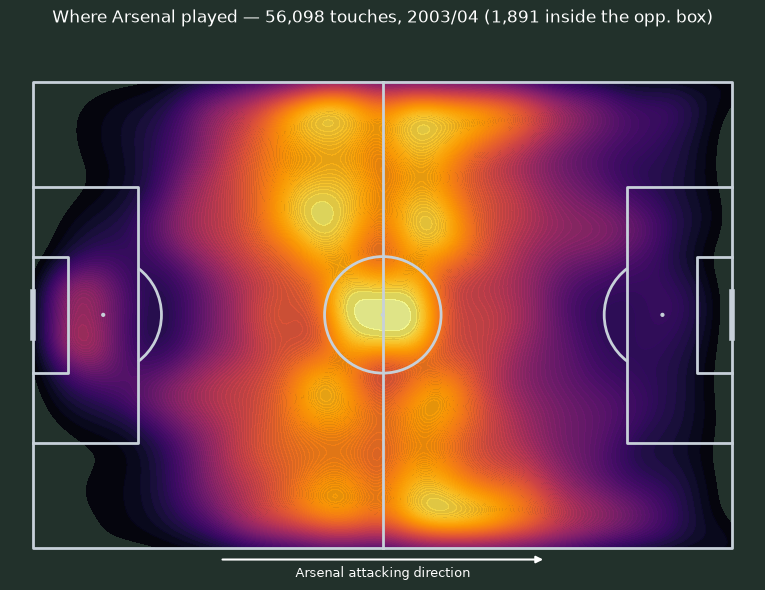

In [2]:
# "Touch" = any on-ball action (pass, carry, shot, dribble, reception) so the box is
# represented honestly. Smooth KDE, but a LOW threshold so low-density-but-real zones
# like the attacking box stay visible instead of being clipped to transparent.
TOUCH = ["Pass", "Ball Receipt*", "Carry", "Shot", "Dribble"]
onball = ars[ars["type"].isin(TOUCH) & ars["location_x"].notna()]

pitch = Pitch(**PITCH_KW, line_zorder=2)
fig, ax = pitch.draw(figsize=(9, 6))
fig.set_facecolor("#22312b")
pitch.kdeplot(onball["location_x"], onball["location_y"], ax=ax,
              fill=True, levels=100, thresh=0.01, cmap="inferno", alpha=0.9)
pitch.annotate("", xy=(88, 82), xytext=(32, 82), ax=ax,
               arrowprops=dict(arrowstyle="-|>", color="w", lw=1.5))
pitch.text(60, 85, "Arsenal attacking direction", ax=ax, color="w",
           ha="center", fontsize=9)

nbox = int(((onball["location_x"] >= 102) & onball["location_y"].between(18, 62)).sum())
ax.set_title(f"Where Arsenal played — {len(onball):,} touches, 2003/04 "
             f"({nbox:,} inside the opp. box)", color="w", fontsize=12, pad=26)
plt.show()

**Concentrated through the centre, spread to both flanks, tilting forward.** The heaviest activity runs through the middle third and pushes into the attacking half with full-width coverage — a side that built patiently from deep (average touch just inside its own half) and worked the ball wide. Box activity is real but low-volume relative to the midfield circulation: the ball was *worked* into the box for the finish rather than the team camping there.

## 2. Shape & connection — open-play pass network

Nodes are the core XI at their mean involvement location (passes made + received); node size = involvement volume, edge width/opacity = passes exchanged between the pair. Open play only (`Regular Play`), completed passes. This is the positional structure behind the low, stable passing-angle entropy.

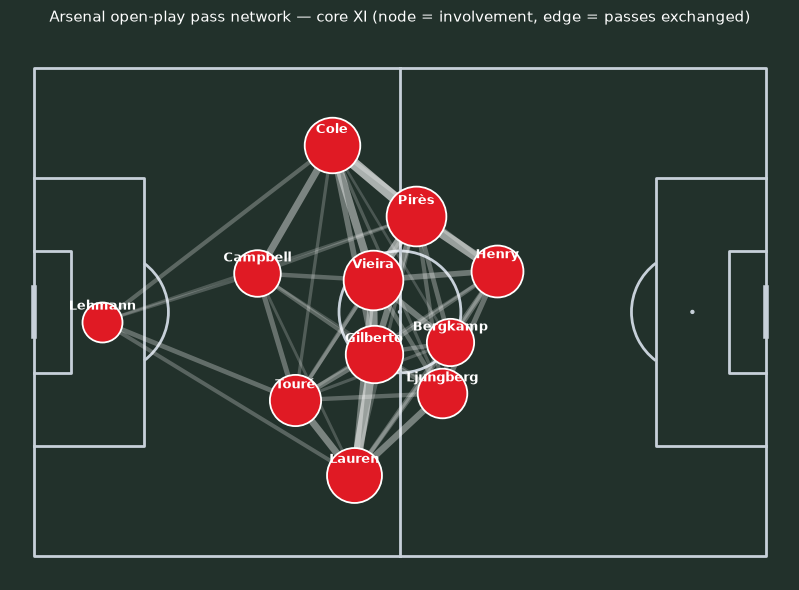

strongest passing links:
  Cole      <-> Pirès       237
  Gilberto  <-> Lauren      199
  Henry     <-> Pirès       197
  Pirès     <-> Vieira      191
  Gilberto  <-> Vieira      160
  Cole      <-> Vieira      155


In [3]:
import collections

op = ars[(ars["type"] == "Pass") & (ars["play_pattern"] == "Regular Play")
         & ars["pass_outcome"].isna()               # null outcome = completed
         & ars["pass_recipient"].notna()
         & ars["player"].isin(CORE) & ars["pass_recipient"].isin(CORE)].copy()
op["p"] = op["player"].map(CORE)
op["r"] = op["pass_recipient"].map(CORE)

made = op.groupby("p")[["location_x", "location_y"]].sum()
recv = op.groupby("r")[["pass_end_x", "pass_end_y"]].sum()
nmade = op["p"].value_counts()
nrecv = op["r"].value_counts()
pos, touches = {}, {}
for pl in CORE.values():
    nm, nr = int(nmade.get(pl, 0)), int(nrecv.get(pl, 0))
    sx = made.loc[pl, "location_x"] if pl in made.index else 0
    sy = made.loc[pl, "location_y"] if pl in made.index else 0
    ex = recv.loc[pl, "pass_end_x"] if pl in recv.index else 0
    ey = recv.loc[pl, "pass_end_y"] if pl in recv.index else 0
    pos[pl] = ((sx + ex) / (nm + nr), (sy + ey) / (nm + nr))
    touches[pl] = nm + nr

edge = collections.Counter()
for a, b in zip(op["p"], op["r"]):
    edge[tuple(sorted((a, b)))] += 1

pitch = Pitch(**PITCH_KW)
fig, ax = pitch.draw(figsize=(9, 6))
fig.set_facecolor("#22312b")
emax = max(edge.values())
for (a, b), w in edge.items():
    if w < 25:                                       # declutter weakest links
        continue
    (x1, y1), (x2, y2) = pos[a], pos[b]
    pitch.lines(x1, y1, x2, y2, lw=1 + 7 * w / emax,
                color="w", alpha=0.12 + 0.5 * w / emax, ax=ax, zorder=1)
tmax = max(touches.values())
for pl, (x, y) in pos.items():
    pitch.scatter(x, y, s=350 + 1500 * touches[pl] / tmax, color="#e01a24",
                  edgecolors="w", linewidth=1.3, ax=ax, zorder=2)
    pitch.text(x, y - 3.6, pl, ax=ax, color="w", ha="center", va="top",
               fontsize=9, fontweight="bold", zorder=3)
ax.set_title("Arsenal open-play pass network — core XI "
             "(node = involvement, edge = passes exchanged)",
             color="w", fontsize=11, pad=16)
plt.show()

top = sorted(edge.items(), key=lambda kv: -kv[1])[:6]
print("strongest passing links:")
for (a, b), w in top:
    print(f"  {a:9} <-> {b:9} {w:5d}")

**A settled spine with a dominant left channel.** The heaviest link in the whole network is Cole–Pirès (237 open-play passes), with the Vieira–Gilberto pivot central and most-involved. The forwards sit highest up the pitch with Henry the furthest-advanced outlet — the positional structure behind the low, stable passing-angle entropy.

## 3. Style signature — home vs away

Each axis is scaled to Arsenal's own 2003/04 range (so this is Arsenal against itself, not the league) and oriented so **outward = more possession-dominant / positional**. Home and away polygons over the same axes show which traits are fixed identity and which flex with venue — the Phase 2 finding, drawn.

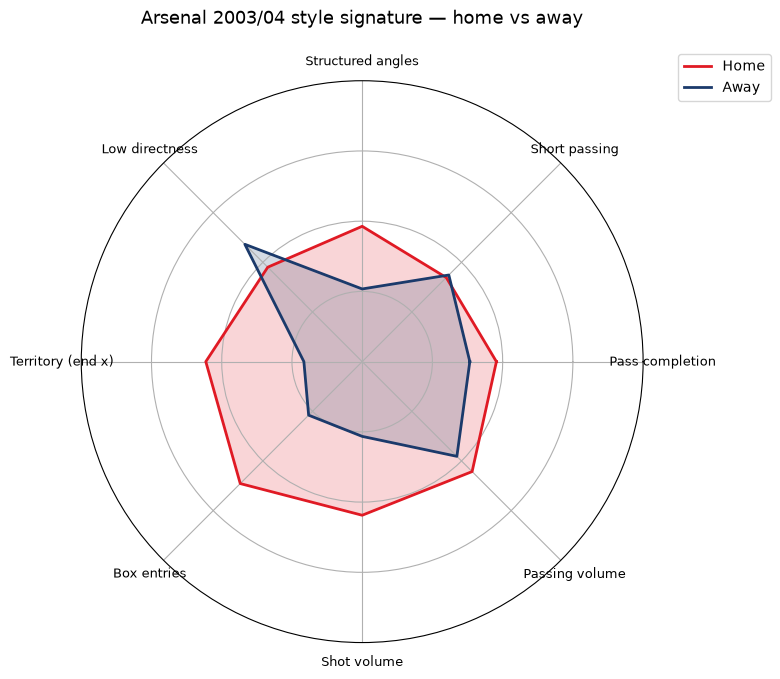

home - away gap per axis (normalised):
  Pass completion      +0.09
  Short passing        -0.01
  Structured angles    +0.22
  Low directness       -0.12
  Territory (end x)    +0.35
  Box entries          +0.34
  Shot volume          +0.28
  Passing volume       +0.08


In [4]:
A = pd.read_csv(FEATURES_DIR / "match_team_style.csv")
A = A[A["team"] == "Arsenal"].copy()
A["home"] = (A["venue"] == "home").astype(int)

# (label, column, invert?) invert => outward means shorter / less direct / more structured
AXES = [
    ("Pass completion", "pass_completion_pct", False),
    ("Short passing", "avg_pass_length_m", True),
    ("Structured angles", "pi_angle_entropy", True),
    ("Low directness", "rp6_mean_directness", True),
    ("Territory (end x)", "poss_mean_end_x", False),
    ("Box entries", "poss_ends_box_pct", False),
    ("Shot volume", "shots", False),
    ("Passing volume", "passes", False),
]
def norm(col, invert):
    v = A[col]; lo, hi = v.min(), v.max()
    z = (v - lo) / (hi - lo) if hi > lo else v * 0 + 0.5
    return 1 - z if invert else z

N = pd.DataFrame({lab: norm(col, inv) for lab, col, inv in AXES})
N["home"] = A["home"].values
home_mean = N[N["home"] == 1].drop(columns="home").mean()
away_mean = N[N["home"] == 0].drop(columns="home").mean()

labels = [a[0] for a in AXES]
ang = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
ang = np.concatenate([ang, ang[:1]])
close = lambda s: np.concatenate([s.values, s.values[:1]])

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for series, c, lab in [(home_mean, "#e01a24", "Home"), (away_mean, "#1b3a6b", "Away")]:
    ax.plot(ang, close(series), color=c, lw=2, label=lab)
    ax.fill(ang, close(series), color=c, alpha=0.18)
ax.set_xticks(ang[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75]); ax.set_yticklabels([]); ax.set_ylim(0, 1)
ax.set_title("Arsenal 2003/04 style signature — home vs away", fontsize=13, pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.24, 1.06))
plt.tight_layout(); plt.show()

print("home - away gap per axis (normalised):")
for lab in labels:
    print(f"  {lab:20} {home_mean[lab] - away_mean[lab]:+.2f}")

**The identity axes overlap; the output axes swing.** Pass completion, short passing and structured angles sit at nearly the same radius home and away — the mechanical core is venue-proof. Territory, box entries and shot volume bulge at home — the same venue lever Phase 2 isolated, now visible as the difference between two polygons.

## Synthesis — the portrait

Three views, one identity: Arsenal 2003/04 were a **high, wide, positional possession side** — they controlled the middle third and worked the ball forward with full width (heatmap), built through a settled spine with a dominant left channel (network), and kept their passing mechanics fixed while flexing territory and output with venue (radar). This is the *what* behind Phase 2's validated *whether*.

**Into Phase 3.** This portrait is the reference the cross-era comparison is drawn against: the validated **identity** features form the design matrix, the **context** features are retained as venue/opponent covariates, and dropped/redundant features are excluded — the same frozen registry contract, now with a visual fingerprint to compare Leicester 2015/16 against.